# Model building for golf putting

This case study reproduces the model-building sequence in Andrew Gelman's
[golf putting case study](https://mc-stan.org/learn-stan/case-studies/golf.html) using Bambi. This work is a demonstration of iterative model building using a Bayesian workflow.

In [1]:
# | code-fold: true
%config InlineBackend.figure_format = "retina"
%config InlineBackend.print_figure_kwargs = {'bbox_inches': None}

import arviz as az
import bambi as bmb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import xlogy

plt.style.use("bambi.mplstyle")


def plot_prediction_ribbon(ax, predictions, *, label, color=None):
    predictions = predictions.sort_values("distance")
    lower = next(column for column in predictions if column.startswith("lower_"))
    upper = next(column for column in predictions if column.startswith("upper_"))
    (line,) = ax.plot(
        predictions["distance"],
        predictions["estimate"],
        label=label,
        color=color,
    )
    ax.fill_between(
        predictions["distance"],
        predictions[lower],
        predictions[upper],
        color=line.get_color(),
        alpha=0.2,
    )


## The original putting data

The observations are aggregate counts of putting attempts and successes from 2 through 20 feet from the hole.

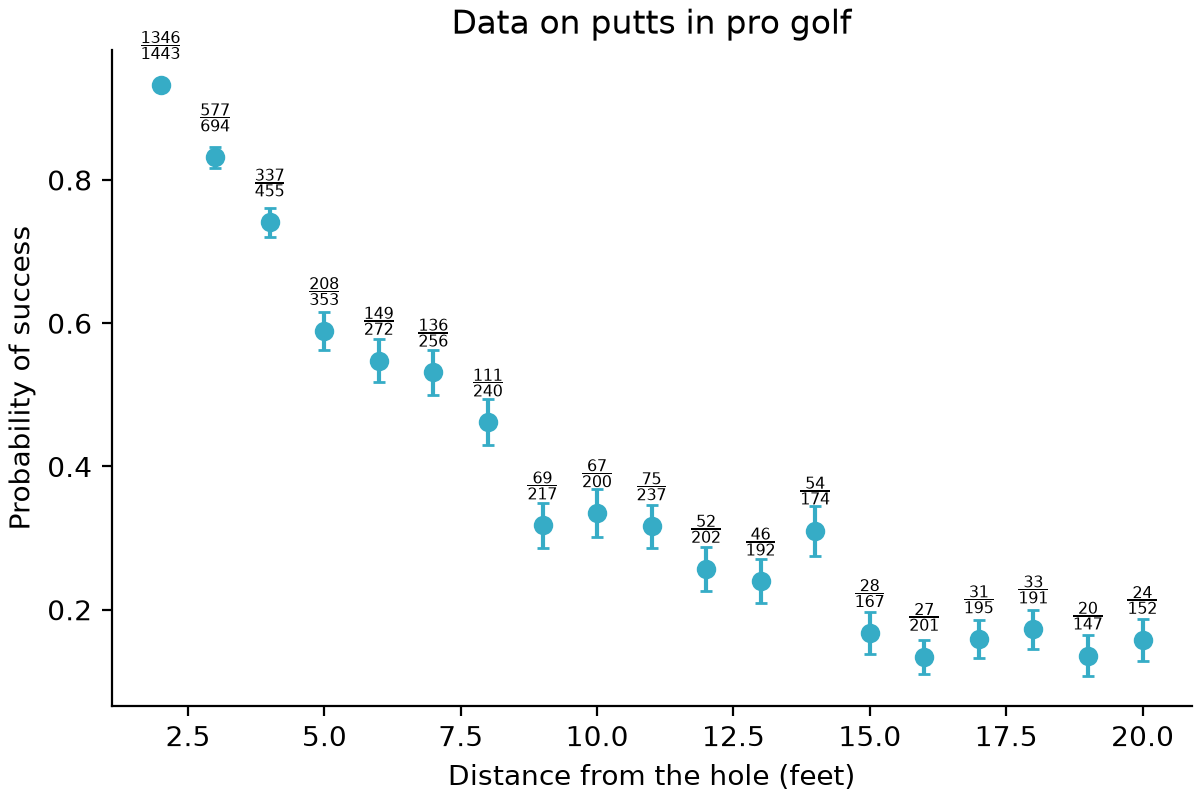

In [2]:
golf = pd.read_csv("data/golf.csv")
golf["distance"] = golf["distance"].astype(float)
golf["success_rate"] = golf["successes"] / golf["attempts"]

standard_error = np.sqrt(
    golf["success_rate"] * (1 - golf["success_rate"]) / golf["attempts"]
)
fig, ax = plt.subplots()
ax.errorbar(
    golf["distance"],
    golf["success_rate"],
    yerr=standard_error,
    fmt="o",
    capsize=2,
)
for observation in golf.itertuples():
    ax.annotate(
        rf"$\frac{{{observation.successes}}}{{{observation.attempts}}}$",
        (observation.distance, observation.success_rate),
        xytext=(0, 12),
        textcoords="offset points",
        ha="center",
        fontsize=8,
    )
ax.set(
    title="Data on putts in pro golf",
    xlabel="Distance from the hole (feet)",
    ylabel="Probability of success",
)
plt.show()


### A conventional logistic regression

A natural starting point is a Binomial regression with a linear predictor on the log-odds scale:

$$
y_j \sim \operatorname{Binomial}(n_j, p_j), \qquad
\operatorname{logit}(p_j) = a + b x_j.
$$

This is a standard Bambi generalized linear model. `prop()` is used to pass successes and attempts, so the binomial model can retain the sample size behind each data point.

NUTS[nutpie]: [distance, Intercept_centered]


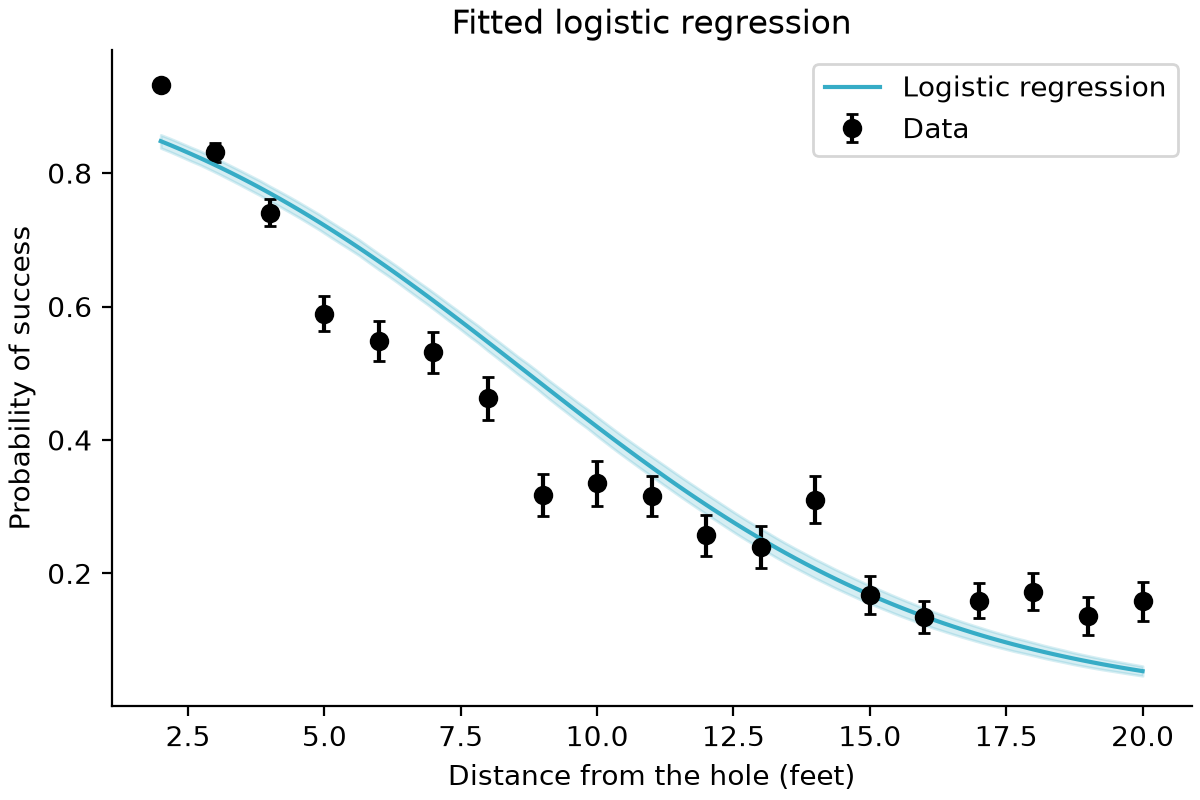

In [3]:
logistic_model = bmb.Model(
    "prop(successes, attempts) ~ distance",
    golf,
    family="binomial",
)
logistic_idata = logistic_model.fit(random_seed=123, progressbar=False)

logistic_predictions = bmb.interpret.predictions(
    logistic_model,
    logistic_idata,
    conditional={"distance": np.linspace(2, 20, 100)},
).summary

fig, ax = plt.subplots()
ax.errorbar(
    golf["distance"],
    golf["success_rate"],
    yerr=standard_error,
    fmt="o",
    color="black",
    capsize=2,
    label="Data",
)
plot_prediction_ribbon(ax, logistic_predictions, label="Logistic regression")
ax.set(
    title="Fitted logistic regression",
    xlabel="Distance from the hole (feet)",
    ylabel="Probability of success",
)
ax.legend()
plt.show()

This is a convenient first pass. It correctly establishes a monotonically decreasing behavior. However, the shape is a poor fit to the data. Extrapolating toward zero distance does not force the success probability toward one. After a handful of feet it overestimates success, and underestimates the longest putts.

## A model from first principles

A golf ball of radius $r$ can enter a hole of radius $R$ when its angular error is smaller than

$$
\theta(x) = \sin^{-1}\left(\frac{R-r}{x}\right).
$$

Assume the golfer aims straight and the realized angle is normally distributed around zero with
standard deviation $\sigma_{\mathrm{angle}}$. The probability that its magnitude is within the
threshold is

$$
p_{\mathrm{angle}}(x) =
2\Phi\left(\frac{\theta(x)}{\sigma_{\mathrm{angle}}}\right)-1.
$$

The radii are converted from inches to feet to match `distance`.

In [4]:
golf["ball_radius"] = (1.68 / 2) / 12
golf["hole_radius"] = (4.25 / 2) / 12

angle_probability_expression = (
    "2 * normal_cdf("
    "asin((hole_radius - ball_radius) / distance) / sigma_angle"
    ") - 1"
)
angle_formula = bmb.Formula(
    f"prop(successes, attempts) ~ {angle_probability_expression}",
    nlpars=("sigma_angle",),
)

angle_model = bmb.Model(
    angle_formula,
    golf,
    family="binomial",
    link="identity",
    priors={"sigma_angle": bmb.Prior("HalfNormal", sigma=0.5)},
)
angle_idata = angle_model.fit(random_seed=123, progressbar=False)

The nonlinear expression returns a probability, so the Binomial parent uses the identity
link. `sigma_angle`, the standard deviation of shot error, is in
radians, so we can convert it to degrees to get the angular error.

In [5]:
sigma_angle_degrees = np.rad2deg(angle_idata.posterior["sigma_angle"])
az.summary(sigma_angle_degrees.rename("sigma_angle_degrees"))


The posterior mean is approximately 1.53 degrees. We can compare
the statistical and physical curves through the same `interpret` API.

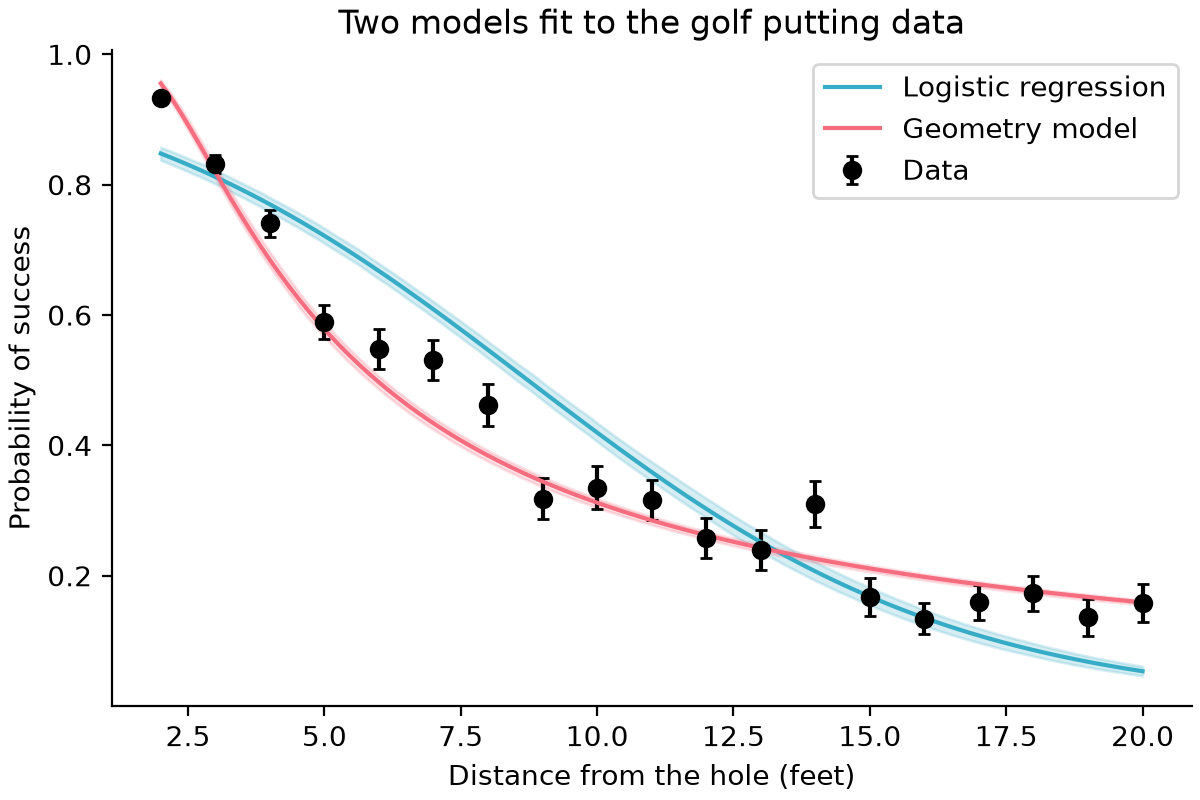

In [6]:
distance_grid = np.linspace(2, 20, 100)

logistic_predictions = bmb.interpret.predictions(
    logistic_model,
    logistic_idata,
    conditional={"distance": distance_grid},
).summary
angle_predictions = bmb.interpret.predictions(
    angle_model,
    angle_idata,
    conditional={"distance": distance_grid},
).summary

fig, ax = plt.subplots()
ax.errorbar(
    golf["distance"],
    golf["success_rate"],
    yerr=standard_error,
    fmt="o",
    color="black",
    capsize=2,
    label="Data",
)
plot_prediction_ribbon(ax, logistic_predictions, label="Logistic regression")
plot_prediction_ribbon(ax, angle_predictions, label="Geometry model")
ax.set(
    title="Two models fit to the golf putting data",
    xlabel="Distance from the hole (feet)",
    ylabel="Probability of success",
)
ax.legend()
plt.show()

The first-principles curve captures the short-distance and overall shape much better.

## Testing the model on new data

Gelman's case study includes a larger dataset from Mark Broadie, containing many more attempts and extending to 75 feet. We start by seeing how the existing angular model performs in the new regime by comparing its posterior expected probability with the new observations.

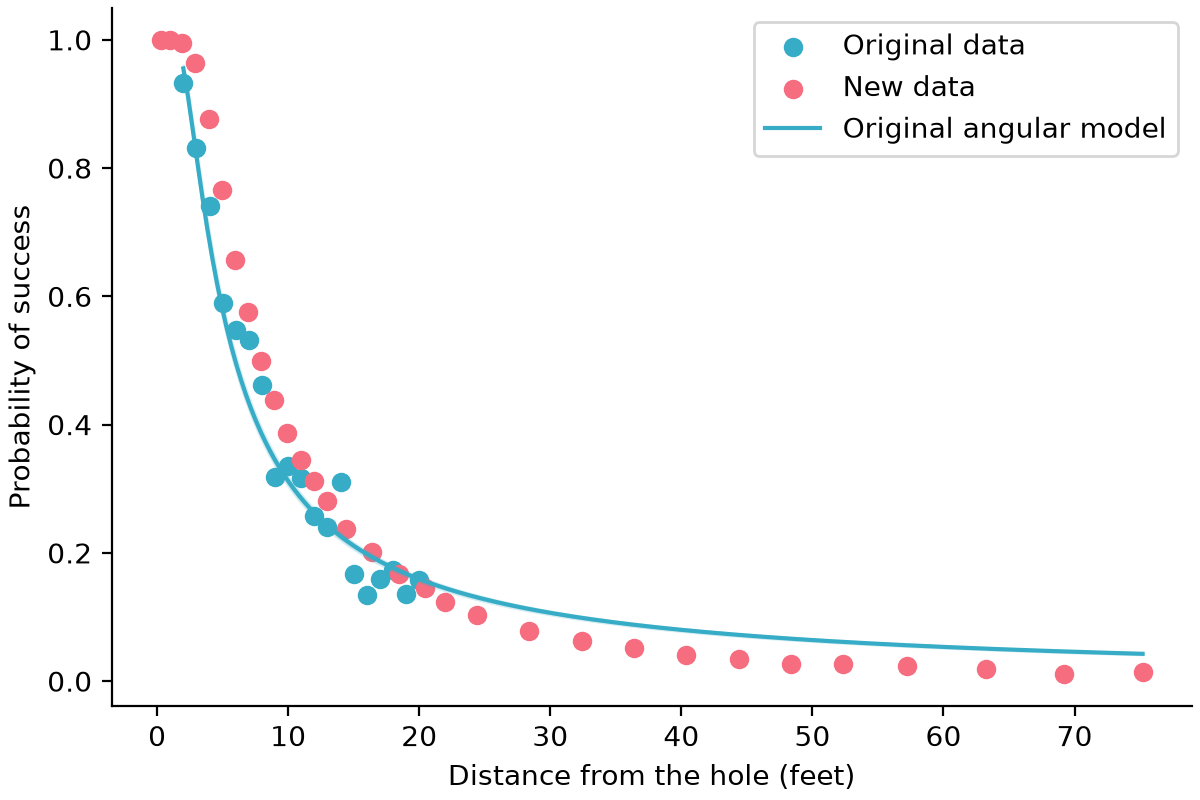

In [7]:
golf_extended = pd.read_csv("data/golf_extended.csv")
golf_extended["distance"] = golf_extended["distance"].astype(float)
golf_extended["success_rate"] = golf_extended["successes"] / golf_extended["attempts"]
golf_extended["ball_radius"] = (1.68 / 2) / 12
golf_extended["hole_radius"] = (4.25 / 2) / 12

extended_distance_grid = np.linspace(2, golf_extended["distance"].max(), 200)
angle_on_new = bmb.interpret.predictions(
    angle_model,
    angle_idata,
    conditional={"distance": extended_distance_grid},
).summary

fig, ax = plt.subplots()
ax.scatter(
    golf["distance"],
    golf["success_rate"],
    label="Original data",
)
ax.scatter(
    golf_extended["distance"],
    golf_extended["success_rate"],
    label="New data",
)
plot_prediction_ribbon(ax, angle_on_new, label="Original angular model")
ax.set(
    xlabel="Distance from the hole (feet)",
    ylabel="Probability of success",
)
ax.legend()
plt.show()


The model overpredicts long putts. Angular accuracy is not enough: a putt must also be struck hard
enough to reach the hole, but not so hard that it rolls across without falling.

## Accounting for how hard the ball is hit

Following the original study, suppose a golfer aims one foot past the hole and has multiplicative distance
error with standard deviation $\sigma_{\mathrm{distance}}$. A putt is struck acceptably when the distance the ball would travel lies between $x$ and $x+3$ feet. Its distance-success probability is

$$
p_{\mathrm{distance}}(x) =
\Phi\left(\frac{2}{(x+1)\sigma_{\mathrm{distance}}}\right)
-
\Phi\left(\frac{-1}{(x+1)\sigma_{\mathrm{distance}}}\right).
$$

Assuming angular and distance errors are independent, the complete success probability is their product: 
$p_{\mathrm{angle}}p_{\mathrm{distance}}$.

In [8]:
golf_extended["overshot"] = 1.0
golf_extended["distance_tolerance"] = 3.0

distance_error_scale_expression = "(distance + overshot) * sigma_distance"
distance_upper_bound_expression = (
    f"(distance_tolerance - overshot) / ({distance_error_scale_expression})"
)
distance_lower_bound_expression = f"-overshot / ({distance_error_scale_expression})"
distance_probability_expression = (
    f"normal_cdf({distance_upper_bound_expression}) - "
    f"normal_cdf({distance_lower_bound_expression})"
)
success_probability_expression = (
    f"({angle_probability_expression}) * ({distance_probability_expression})"
)
angle_distance_formula = bmb.Formula(
    f"prop(successes, attempts) ~ {success_probability_expression}",
    nlpars=("sigma_angle", "sigma_distance"),
)

angle_distance_model = bmb.Model(
    angle_distance_formula,
    golf_extended,
    family="binomial",
    link="identity",
    priors={
        "sigma_angle": bmb.Prior("HalfNormal", sigma=1),
        "sigma_distance": bmb.Prior("HalfNormal", sigma=1),
    },
)
angle_distance_idata = angle_distance_model.fit(
    random_seed=123,
    cores=1,
    progressbar=False,
)

az.summary(
    angle_distance_idata,
    var_names=["sigma_angle", "sigma_distance"],
)

/var/folders/yp/g4z_ylx565j4hzgny6j2phtc0000gn/T/ipykernel_3871/4173735732.py:54: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


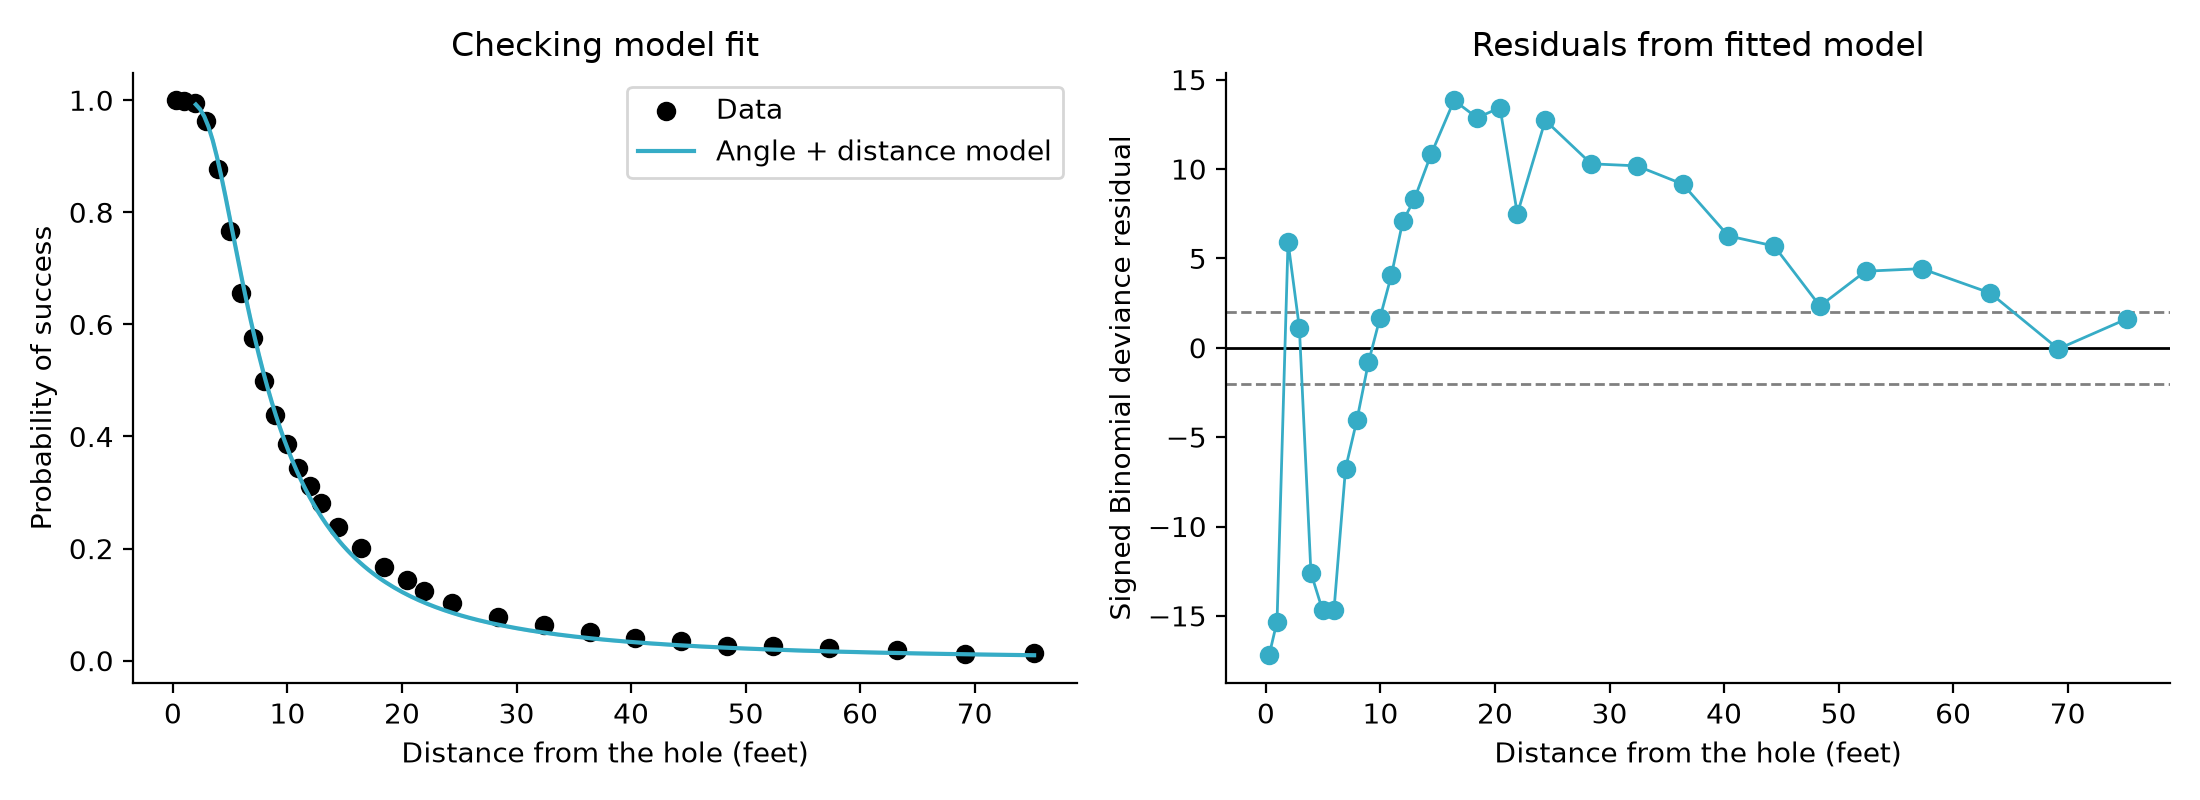

In [9]:
angle_distance_fitted = angle_distance_model.predict(
    angle_distance_idata,
    data=golf_extended,
    inplace=False,
)
fitted_probability = (
    angle_distance_fitted.predictions["p"].mean(("chain", "draw")).to_numpy()
)
observed_probability = golf_extended["success_rate"].to_numpy()
successes = golf_extended["successes"].to_numpy()
attempts = golf_extended["attempts"].to_numpy()
failures = attempts - successes
expected_successes = attempts * fitted_probability
expected_failures = attempts * (1 - fitted_probability)
binomial_deviance = 2 * (
    xlogy(successes, successes / expected_successes)
    + xlogy(failures, failures / expected_failures)
)
deviance_residual = np.sign(observed_probability - fitted_probability) * np.sqrt(
    binomial_deviance
)
angle_distance_predictions = bmb.interpret.predictions(
    angle_distance_model,
    angle_distance_idata,
    conditional={"distance": extended_distance_grid},
).summary

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(
    golf_extended["distance"],
    golf_extended["success_rate"],
    color="black",
    label="Data",
)
plot_prediction_ribbon(
    axes[0], angle_distance_predictions, label="Angle + distance model"
)
axes[0].set(
    title="Checking model fit",
    xlabel="Distance from the hole (feet)",
    ylabel="Probability of success",
)
axes[0].legend()

axes[1].axhline(0, color="black", linewidth=1)
axes[1].axhline(2, color="gray", linewidth=1, linestyle="--")
axes[1].axhline(-2, color="gray", linewidth=1, linestyle="--")
axes[1].plot(golf_extended["distance"], deviance_residual, linewidth=1, marker="o")
axes[1].set(
    title="Residuals from fitted model",
    xlabel="Distance from the hole (feet)",
    ylabel="Signed Binomial deviance residual",
)
fig.tight_layout()
plt.show()


Unlike the provisional fit in the original case study, this model samples cleanly and its fitted
curve _looks_ close to the data. However, as depicted on the right, many signed Binomial
deviance residuals fall well beyond the $\pm 2$ reference lines and show a systematic pattern.
The large number of attempts in the new dataset makes the Binomial likelihood require closer
agreement than this model can provide.

## Modeling the remaining variation

Gelman and Broadie address the misspecification by approximating each observed proportion with a
Normal distribution and adding an irreducible residual scale $\sigma_y$:

$$
\frac{y_j}{n_j} \sim \operatorname{Normal}\left(
p_j,
\sqrt{\frac{p_j(1-p_j)}{n_j}+\sigma_y^2}
\right).
$$

The nonlinear parameter graph can express this directly. The mean `mu` composes the angle and
distance probabilities, while Gaussian `sigma` depends on both `mu` and the separately estimated
`sigma_y`. Bambi resolves those dependencies before constructing the PyMC graph.

In [10]:
joint_probability_expression = "p_angle * p_distance"
residual_scale_expression = "sqrt(mu * (1 - mu) / attempts + sigma_y ** 2)"
golf_residual_formula = bmb.Formula(
    f"success_rate ~ {joint_probability_expression}",
    f"p_angle ~ {angle_probability_expression}",
    f"p_distance ~ {distance_probability_expression}",
    f"sigma ~ {residual_scale_expression}",
    nlpars=(
        "p_angle",
        "p_distance",
        "sigma_angle",
        "sigma_distance",
        "sigma_y",
    ),
)

golf_residual_model = bmb.Model(
    golf_residual_formula,
    golf_extended,
    family="gaussian",
    link="identity",
    priors={
        "sigma_angle": bmb.Prior("HalfNormal", sigma=1),
        "sigma_distance": bmb.Prior("HalfNormal", sigma=1),
        "sigma_y": bmb.Prior("HalfNormal", sigma=0.1),
    },
)
golf_residual_idata = golf_residual_model.fit(
    random_seed=123,
    cores=1,
    progressbar=False,
)

az.summary(
    golf_residual_idata,
    var_names=[
        "sigma_angle",
        "sigma_distance",
        "sigma_y",
    ],
)

/var/folders/yp/g4z_ylx565j4hzgny6j2phtc0000gn/T/ipykernel_3871/1825735004.py:65: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


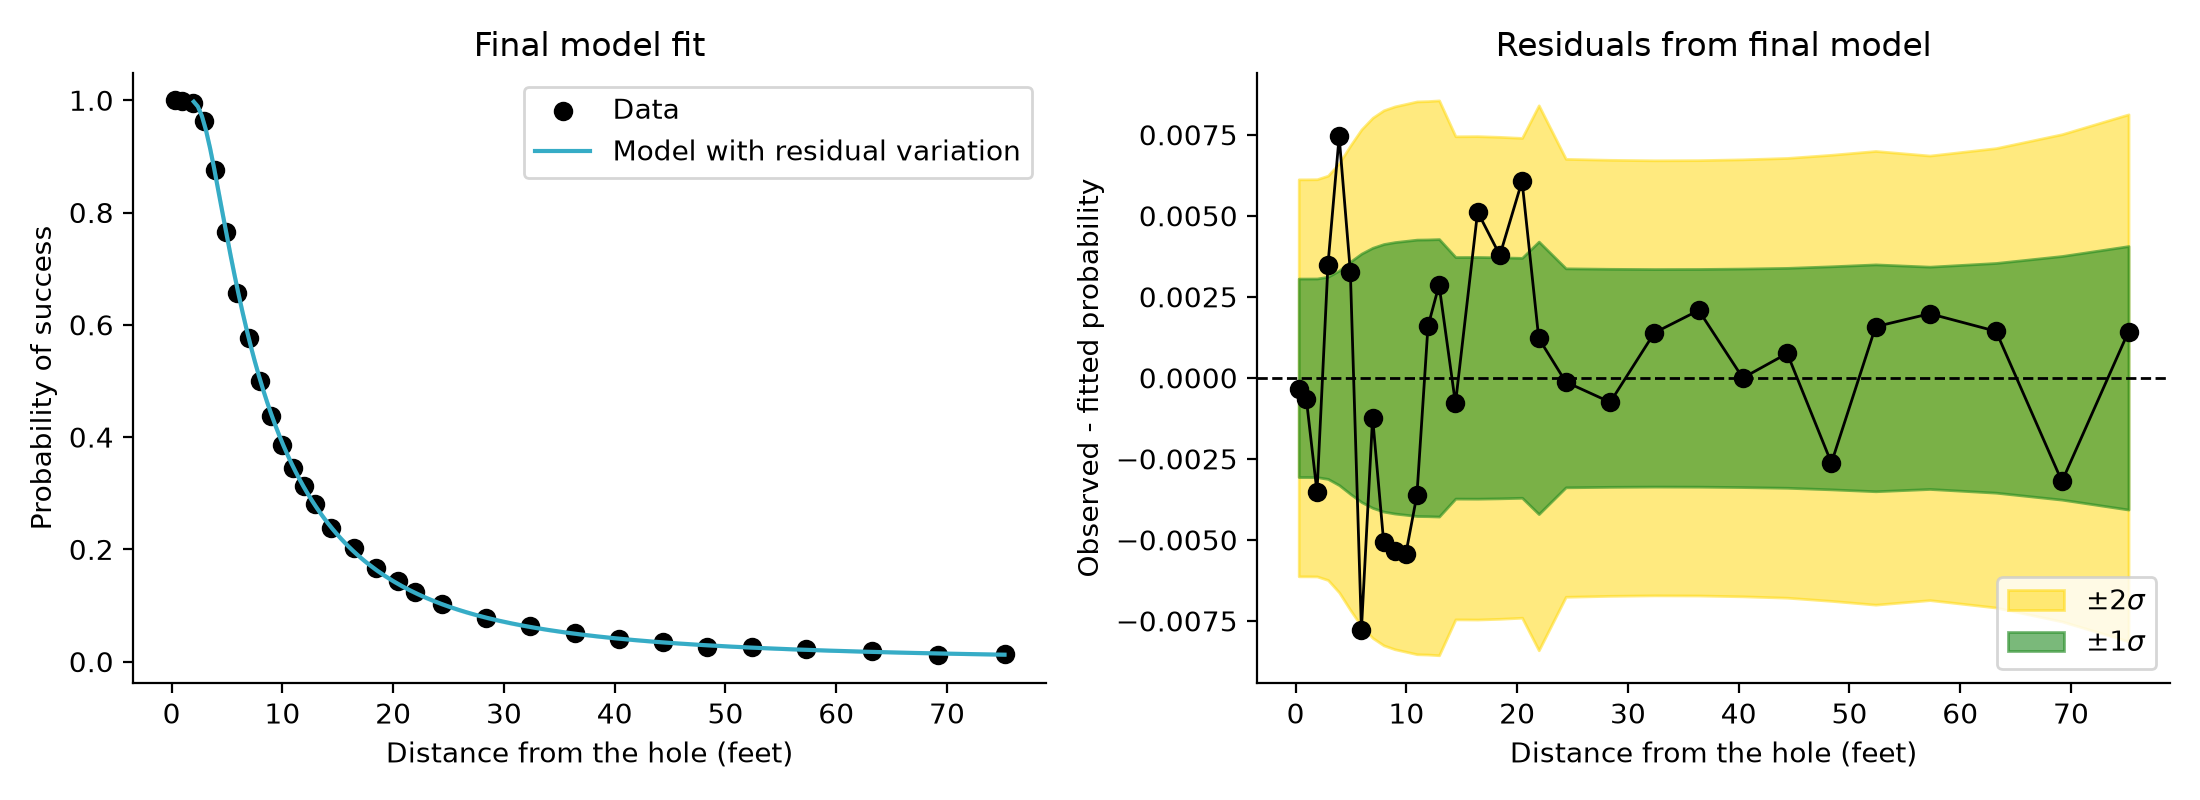

In [11]:
golf_residual_fitted = golf_residual_model.predict(
    golf_residual_idata,
    data=golf_extended,
    kind="response_params",
    inplace=False,
)
final_fitted_probability = golf_residual_fitted.predictions["mu"].mean(
    ("chain", "draw")
)
final_fitted_sigma = golf_residual_fitted.predictions["sigma"].mean(("chain", "draw"))
final_residual = golf_extended["success_rate"] - final_fitted_probability
golf_residual_predictions = bmb.interpret.predictions(
    golf_residual_model,
    golf_residual_idata,
    conditional={"distance": extended_distance_grid},
).summary

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(
    golf_extended["distance"],
    golf_extended["success_rate"],
    color="black",
    label="Data",
)
plot_prediction_ribbon(
    axes[0], golf_residual_predictions, label="Model with residual variation"
)
axes[0].set(
    title="Final model fit",
    xlabel="Distance from the hole (feet)",
    ylabel="Probability of success",
)
axes[0].legend()

axes[1].axhline(0, color="black", linewidth=1, linestyle="--")
axes[1].fill_between(
    golf_extended["distance"],
    -2 * final_fitted_sigma,
    2 * final_fitted_sigma,
    color="gold",
    alpha=0.5,
    label=r"$\pm 2\sigma$",
)
axes[1].fill_between(
    golf_extended["distance"],
    -final_fitted_sigma,
    final_fitted_sigma,
    color="forestgreen",
    alpha=0.6,
    label=r"$\pm 1\sigma$",
)
axes[1].plot(
    golf_extended["distance"],
    final_residual,
    color="black",
    linewidth=1,
    marker="o",
)
axes[1].set(
    title="Residuals from final model",
    xlabel="Distance from the hole (feet)",
    ylabel="Observed - fitted probability",
)
axes[1].legend()
fig.tight_layout()
plt.show()


The final model estimates `sigma_y` at approximately 0.003, corresponding to an additional
residual scale of 0.3 percentage points. Most of the residuals now fall within the fitted $\pm 2\sigma$
band, and the pattern from the Binomial model is largely gone.